# <span style="color:red; font-size:25px"> DATASCI 151 - Quiz #4 </span>

<font size = "4" >
This quiz is open book 

<br>

- You <span style="color:red"> CAN </span> use all material from the course repo

- You should <span style="color:red"> NOT </span> use other resources outside the course repo.

- You should <span style="color:red"> NOT </span> collaborate with other students

<!-- - This is a graded quiz. Use of LLMs or any AI tools is <span style="color:red"> NOT ALLOWED. </span> -->

- AI assistance is <span style="color:red"> NOT </span> permitted for this assignment.

- To get full credit, the code should work as intended. But try to attempt every problem - you can still receive partial credit.

<br>

Print the following string:

"I will abide by Emory's code of conduct"

In [1]:
print("I will abide by Emory's code of conduct")

I will abide by Emory's code of conduct


<font size = "4">

Import any packages you would like in the cell below. Or, import them as needed later in the notebook.

In [2]:
# import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

<font size = "4">

**Q1** Transforming variables

<font size = "3">

During a roadside physics study, researchers measured the speed of various vehicles as they passed a checkpoint using a radar gun. The mass of each vehicle was estimated based on manufacturer specifications for the vehicle model.

The speeds were recorded in **miles per hour (mph)** and masses were recorded in **kilograms (kg)**.

1. Read in the file "speed_mass.csv" from the quiz_data folder, saving it as a DataFrame

2. Using the `.apply` method, define a Pandas Series that contains the speed in terms of **meters per second** based on the following formula:

$$ \textrm{speed in meters per second} = \frac{1609.34}{3600} \times \textrm{speed in miles per hour}$$

3. Add a new column to the DataFrame named "Kinetic Energy (J)" which contains the kinetic energy of the car. The formula for kinetic energy is given below, where $m$ is the mass in kilograms and $v$ is the velocity in meters per second.

$$ \textrm{kinetic energy} = \frac{1}{2}mv^2$$

In [3]:
# your code here
pd0 = pd.read_csv("quiz_data/speed_mass.csv")
def speed_in_ms(speed):
    return (1609.34/3600) * speed
pd0_series = pd0["Speed (mph)"].apply(speed_in_ms)

ke_df = pd.DataFrame({"Vehicle ID": pd0["Vehicle ID"], "Speed (mph)": pd0["Speed (mph)"],
                       "Mass (kg)": pd0["Mass (kg)"], "Kinetic Energy (J)": (pd0_series**2)*pd0["Mass (kg)"]*(1/2)})
print(ke_df)

print(((1609.34/3600 * 42.5)**2)*1441.67*(1/2))


    Vehicle ID  Speed (mph)  Mass (kg)  Kinetic Energy (J)
0         QA22         42.5    1441.67        2.601982e+05
1         TR80         77.0    1577.65        9.346580e+05
2         KA25         63.9    2276.71        9.289023e+05
3         AF65         55.9    1475.38        4.606681e+05
4         FP80         29.4    1254.24        1.083268e+05
..         ...          ...        ...                 ...
245       CX14         75.7    1530.03        8.760973e+05
246       RT94         45.7    1875.48        3.913861e+05
247       TE40         78.0    1116.60        6.788088e+05
248       MK90         77.8    2461.59        1.488797e+06
249       JL98         71.2    2479.32        1.255895e+06

[250 rows x 4 columns]
260198.22863504378


<font size = "4">

**Q2** Random Assignment

<font size = "3">

Read in the file "SOCR-HeightWeight.csv" from the quiz_data folder, storing it as a DataFrame. It contains two columns "Height(Inches)" and "Weight(pounds)".

1. Use some method to randomly assign each person in the dataset into four groups: 1, 2, 3, 4. Each group should be assigned with equal probability (25% chance of being placed in a given group). You can use any appropriate method to peform the random assignment.

2. Add a new column to the DataFrame with the name "GroupID", where each entry is either 1, 2, 3, or 4.


In [4]:
# your code here
df1 = pd.read_csv("quiz_data/SOCR-HeightWeight.csv")
num_rows = df1.shape[0]  
df1["GroupID"] = np.random.choice(["1", "2", "3", "4"], size=num_rows)

print(df1)

       Height(Inches)  Weight(Pounds) GroupID
0            65.78331        112.9925       1
1            71.51521        136.4873       4
2            69.39874        153.0269       1
3            68.21660        142.3354       3
4            67.78781        144.2971       4
...               ...             ...     ...
24995        69.50215        118.0312       1
24996        64.54826        120.1932       1
24997        64.69855        118.2655       1
24998        67.52918        132.2682       1
24999        68.87761        124.8742       3

[25000 rows x 3 columns]


<font size = "4">

**Q3** Random assignment

<font size = "3">

Continue to use the DataFrame you created in **Q3**

1. Use `.query` to extract all players in Group 1, assigning it to a new DataFrame called `group_1`

2. Use `.query` to extract all players in Group 2, assigning it to a new DataFrame called `group_2`

3. Use ``matplotlib.pyplot.subplots`` to create two side by side scatter plots (1 row, 2 columns)

    - In the left figure, plot the columns ``Height(Inches)`` vs. ``Weight(Pounds)`` for the data in ``group_1`` (so the horizontal axis corresponds to height, the vertical axis corresponds to weight)

    - In the right figure, plot the same variables for ``group_2``

    - Label the axes for **both** plots. Create a title for **both** plots, indicating whether Group 1 or Group 2 is shown.

**Note**: If you can't remember how to use `.subplots`, maximize your partial credit by using two calls to `.scatter` to create two separate plots.

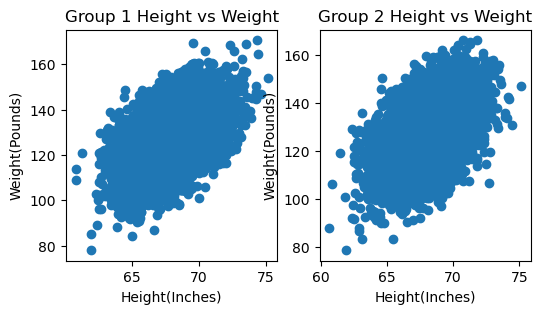

In [5]:
# your code here
group_1 = df1.query("GroupID == '1'")
group_2 = df1.query("GroupID == '2'")

fig, subfig_array = plt.subplots(nrows = 1, ncols = 2,figsize = (6,3))

subfig_array[0].scatter(x =group_1["Height(Inches)"],y = group_1["Weight(Pounds)"])
subfig_array[0].set_title("Group 1 Height vs Weight")
subfig_array[0].set_xlabel("Height(Inches)")
subfig_array[0].set_ylabel("Weight(Pounds)")

subfig_array[1].scatter(x =group_2["Height(Inches)"],y = group_2["Weight(Pounds)"])
subfig_array[1].set_title("Group 2 Height vs Weight")
subfig_array[1].set_xlabel("Height(Inches)")
subfig_array[1].set_ylabel("Weight(Pounds)")

plt.show()

<font size = "4">

**Q4** Recoding Variables

<font size = "3">

Read in the file "datasci185.csv" from the quiz_data folder, assigning it to a DataFrame. The file is a (hypothetical) dataset of students taking DataSci 185 with the columns "Student_ID", "Major", "Year", and "Grade Pct".

1. Recode the "Grade Pct" variable into a categorical variable with the values:

    - "F" if $\textrm{Grade\_Pct} < 55$
    - "D" if $55 \leq \textrm{Grade\_Pct} < 60$
    - "C" if $60 \leq \textrm{Grade\_Pct} < 75$
    - "B" if $75 \leq \textrm{Grade\_Pct} < 87$
    - "A" if $87 \leq \textrm{Grade\_Pct}$

2. Add a column to the DataFrame called "Letter_Grade" corresponding to this new categorical variable.

3. Using Python/Pandas commands, calculate and print out the proportion of "A" students in the course (# of "A" students / # of total students). 

**Note:** Unlike the examples in class, the right endpoint of the intervals/bins are **not** inclusive, but the left ones are!


In [6]:
# your code here
df2 = pd.read_csv("quiz_data/datasci185.csv")

def grade_change(grade):
    if grade < 55:
        return "F"
    elif grade < 60:
        return "D"
    elif grade < 75:
        return "C"
    elif grade < 87:
        return"B"
    else:
        return "A"
    
df2["Grade Pct"] = df2["Grade Pct"].apply(grade_change)

A_students = df2.query("`Grade Pct` == 'A'")

proportion_A_students = (len(A_students["Student_ID"])) / (len(df2["Student_ID"]))

print(proportion_A_students)
    
    

0.42


<font size = "4">

**Q5** Replacing variables

<font size = "3">

Read in the file "constructors.csv" from the quiz_data folder, assigning it to a DataFrame. This dataset contains information about the entities (constructors) that designs and makes the F1 racing cars.

1. In the "nationality" column, replace the values "British", "American", and "Dutch" with the strings "UK", "USA", and "Netherlands", respectively.

2. You should use the ``.replace`` method only **one time** in your solution.

In [7]:
# your code here
df3 = pd.read_csv("quiz_data/constructors.csv")

df3["nationality"] = df3["nationality"].replace(("British", "American", "Dutch"), ("UK", "USA", "Netherlands"))

print(df3)

     constructorId constructorRef            name nationality  \
0                1        mclaren         McLaren          UK   
1                2     bmw_sauber      BMW Sauber      German   
2                3       williams        Williams          UK   
3                4        renault         Renault      French   
4                5     toro_rosso      Toro Rosso     Italian   
..             ...            ...             ...         ...   
206            209          manor  Manor Marussia          UK   
207            210           haas    Haas F1 Team         USA   
208            211   racing_point    Racing Point          UK   
209            213     alphatauri      AlphaTauri     Italian   
210            214         alpine  Alpine F1 Team      French   

                                                   url  
0                 http://en.wikipedia.org/wiki/McLaren  
1              http://en.wikipedia.org/wiki/BMW_Sauber  
2    http://en.wikipedia.org/wiki/Williams_Grand

<font size = "4">

**Q6** Merging

<font size = "3">

Read in the files "sprint_results.csv" and "constructors.csv" from the quiz_data folder, assigning them to two different DataFrames.

Use `pandas.merge` to create a new DataFrame called `df_merged` by combining the two DataFrames you created by reading in the data:

1. The only column they have in common is "constructorId".

2. The DataFrame `df_merged` should have 18 total columns:

    - The first 16 columns should coincide with the 16 columns of the "sprint_results" DataFrame, appearing in the same order. 

    - The last two columns should be "name" and "nationality" which are taken from the "constructors" DataFrame.

3. You only need a single call to `pd.merge` for this problem. Do not use the `.drop` method after merging the DataFrames. Only merge the required columns.

In [8]:
# your code here
df4 = pd.read_csv("quiz_data/sprint_results.csv")
df5 = pd.read_csv("quiz_data/constructors.csv")

df_merged = pd.merge(df4, df5[["constructorId", "name", "nationality"]])

print(df_merged)

    resultId  raceId  driverId  constructorId  number  grid position  \
0          1    1061       830              9      33     2        1   
1          2    1061         1            131      44     1        2   
2          3    1061       822            131      77     3        3   
3          4    1061       844              6      16     4        4   
4          5    1061       846              1       4     6        5   
..       ...     ...       ...            ...     ...   ...      ...   
95        96    1084       848              3      23    11       16   
96        97    1084       852            213      22    14       17   
97        98    1084       849              3       6    19       18   
98        99    1084        20            117       5    20       19   
99       100    1084         4            214      14     8       \N   

   positionText  positionOrder  points  laps       time milliseconds  \
0             1              1       3    17  25:38.426      15